In [1]:
import glob

import scipy.stats as stats
import scipy.integrate
import numpy as np

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [3]:
import pickle
import rubinml

/Users/duncan/Documents/code/physics/repos/rubin_sim/rubin_sim/utils/__init__.py:6: DeprecationWarning: rubin_sim.utils is deprecated, switch to rubin_scheduler.utils
  warnings.warn("rubin_sim.utils is deprecated, switch to rubin_scheduler.utils", DeprecationWarning)


In [4]:
rates_files = glob.glob('/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/*.pickle')

In [5]:
rates_by_mass = {}
for rate_file in rates_files:
  print(rate_file)
  try:
    with open(rate_file, 'rb') as f:
      rates, info = pickle.load(f)
  except:
    print('failed')
    pass
  rates_by_mass[info['pbhmass']] = rubinml.rates_to_rubin_counts(rates)

/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728633317_ut-5_m-1.00e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728633749_ut-5_m-1.78e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728634173_ut-5_m-3.16e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728634596_ut-5_m-5.62e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728635020_ut-5_m-1.00e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728635441_ut-5_m-1.78e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728635865_ut-5_m-3.16e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728636287_ut-5_m-5.62e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728636701_ut-5_m-1.00e-10sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/r

In [6]:
ratedf = pd.DataFrame(rates_by_mass.items(), columns=['pbhmass', 'rate'])

In [7]:
rate = 137208

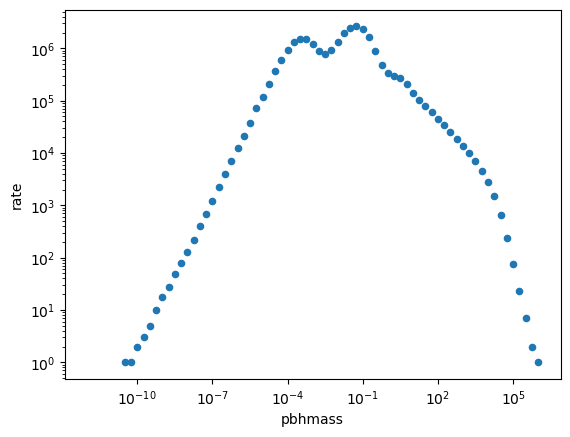

In [8]:

ratedf.plot.scatter('pbhmass', 'rate')
plt.xscale('log')
plt.yscale('log')

In [9]:
def exclusion_from_rate(lambda_0=0,k_obs=0, confidence_level=0.95):
  if lambda_0 == 0:
    return 1
  # Compute the upper limit for the Poisson mean using the inverse CDF
  # ppf gives the value of the parameter such that the CDF is equal to the given percentile
  upper_limit_lambda = stats.poisson.ppf(confidence_level, k_obs + 1)

  # If you have a known baseline rate (lambda_0), calculate the upper limit for the modulation factor (mu)
  upper_limit_mu = upper_limit_lambda / lambda_0

  return min(upper_limit_mu,1)

In [82]:
def bounds_from_rate(lambda_0=0,k_obs=0, confidence_level=0.95):
  if lambda_0 == 0:
    return (0,1)
  # Compute the upper limit for the Poisson mean using the inverse CDF
  # ppf gives the value of the parameter such that the CDF is equal to the given percentile
  upper_limit_lambda = stats.poisson.ppf(confidence_level, k_obs + 1)
  lower_limit_lambda = stats.poisson.ppf(1-confidence_level, k_obs + 1)

  # If you have a known baseline rate (lambda_0), calculate the upper limit for the modulation factor (mu)
  upper_limit_mu = upper_limit_lambda / lambda_0

  lower_limit_mu = lower_limit_lambda / lambda_0

  return (max(lower_limit_mu, 0), min(upper_limit_mu,1))

In [10]:
exclusions = {}
for mass, rate in rates_by_mass.items():
  exclusions[mass] = exclusion_from_rate(rate)

In [11]:
exclusions_min = {}
for mass, rate in rates_by_mass.items():
  exclusions_min[mass] = exclusion_from_rate(rate*0.5+819236, k_obs=819236)

In [12]:
exclusion_df = pd.DataFrame(exclusions.items(), columns=['pbhmass', 'exclusion'])

In [13]:
exclusion_min_df = pd.DataFrame(exclusions_min.items(), columns=['pbhmass', 'exclusion'])

In [14]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k/detections/*baseline_v3.6_10yrs*.pickle')
ndetections = []
masses = []
opsims= []
for file in result_files_wide10k:
  with open(file, 'rb') as f:

    events_info, detections = pickle.load(f)
    
    masses.append(events_info['pbhmass'])
    opsims.append(events_info['opsim'])
    ndetections.append(np.sum(detections)/detections.shape[0])
    # print(detections)

In [4]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k/detections/*.pickle')
event_dfs = []
# ndetections = []
# masses = []
# opsims= []
for file in result_files_wide10k:
  with open(file, 'rb') as f:
    events_info, detections = pickle.load(f)
  with open(events_info['original file'], 'rb') as f:
    events_df, sim_info = pickle.load(f)
  # print(detections)
  events_df=events_df[['crossing_time','umin']]
  events_df['pbhmass'] = events_info['pbhmass']
  events_df['detected'] = (detections.filled(0)==1)
  event_dfs.append(events_df)


In [39]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k/detections/*.pickle')
crossing_time_info = {}
# ndetections = []
# masses = []
# opsims= []
for file in result_files_wide10k:
  with open(file, 'rb') as f:
    events_info, detections = pickle.load(f)
  with open(events_info['original file'], 'rb') as f:
    events_df, sim_info = pickle.load(f)
  # print(detections)
  crossing_time_info[events_info['pbhmass']] = np.percentile(events_df['crossing_time'][(detections.filled(0)==1)], (5,50,95))

In [40]:
result_files_wide10k

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+00sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+01sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+02sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+03sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+04sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+05sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e+06sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e-01sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/detections/baseline_v3.6_10yrs_1.00e-02sm.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k/d

In [69]:
events_df=pd.concat(event_dfs, ignore_index=True)

In [70]:
events_df

,crossing_time,umin,pbhmass,detected
0,420.384557,2.915526,1.000000e+00,True
1,495.775397,3.018684,1.000000e+00,False
2,1899.507509,1.084068,1.000000e+00,True
3,113.289622,2.632362,1.000000e+00,False
4,1221.655194,4.378325,1.000000e+00,False
...,...,...,...,...
1849995,1.544834,3.552415,3.162278e-12,True
1849996,1.205868,4.489523,3.162278e-12,False
1849997,1.296524,3.805762,3.162278e-12,False
1849998,1.083485,3.387984,3.162278e-12,False


In [10]:
events_df.memory_usage()

Index              132
source_index     80000
gall             80000
galb             80000
mu0              80000
dl               80000
umin             80000
crossing_time    80000
lograte          80000
dtype: int64

Text(0, 0.5, 'Crossing time (hours)')

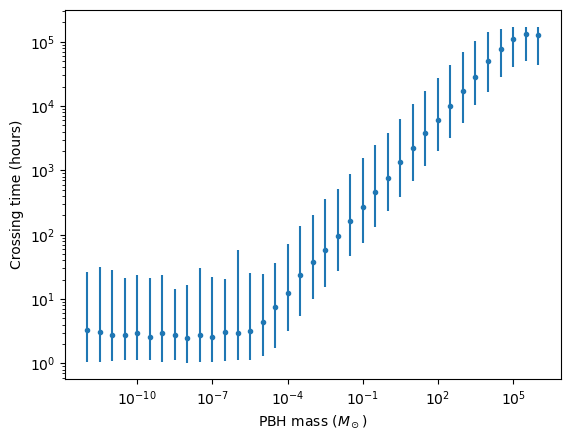

In [6]:
masses = list(crossing_time_info.keys())
cts = [ v[1] for v in crossing_time_info.values()]
errs = np.array([ [v[0],v[2]] for v in crossing_time_info.values()]).T
plt.errorbar(masses, cts, yerr=np.abs(errs-cts), linestyle='None', marker='.')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'PBH mass ($M_\odot$)')
plt.ylabel(r'Crossing time (hours)')

In [7]:
import seaborn as sns

Text(0, 0.5, 'Crossing time (hours)')

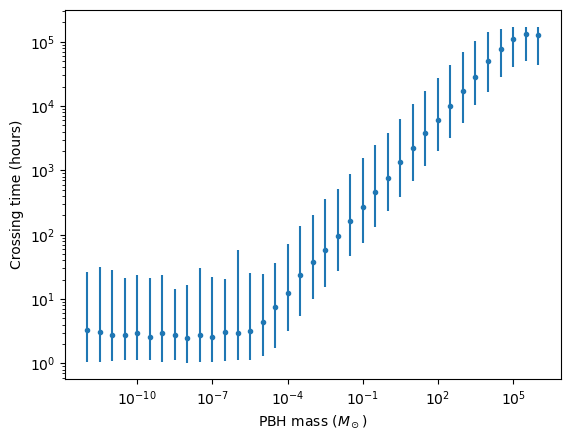

In [ ]:
masses = list(crossing_time_info.keys())

cts = [ v[1] for v in crossing_time_info.values()]
errs = np.array([ [v[0],v[2]] for v in crossing_time_info.values()]).T
plt.errorbar(masses, cts, yerr=np.abs(errs-cts), linestyle='None', marker='.')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'PBH mass ($M_\odot$)')
plt.ylabel(r'Crossing time (hours)')

In [41]:
crossing_time_bounds = {k:[v[0],v[2]] for k,v in crossing_time_info.items()}

Text(0, 0.5, 'Crossing time (hours)')

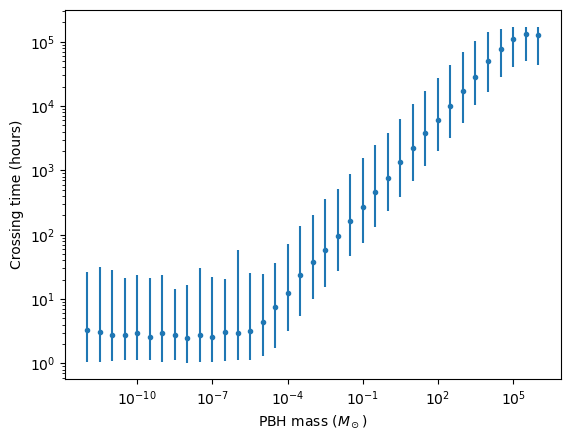

In [ ]:

errs = np.array(list(crossing_time_bounds.values())).T
exclusions_sobh_in_time_df_fisher = pd.DataFrame(exclusions_sobh_in_time_fisher,columns=['pbhmass','time (days)', 'eff','ndetections', 'exclusion'])
df_pivot = np.log10(exclusions_sobh_in_time_df_fisher.pivot(index="time (days)", columns="pbhmass", values="exclusion"))
sns.heatmap(df_pivot, fmt='.1e',cbar_kws={'label': r'log$_{10}(f_{DM})$'})
plt.errorbar(masses, cts, yerr=np.abs(errs-cts), linestyle='None', marker='.')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'PBH mass ($M_\odot$)')
plt.ylabel(r'Crossing time (hours)')

In [19]:
print(np.max(errs.flat))
print(np.min(errs.flat))

171664.3264406399
1.0302886264138902


In [20]:
365*10*24*2

175200

In [44]:
crossing_time_info[10**5]

array([ 40942.21537127, 109292.05247954, 167416.94438874])

In [15]:
def log_fraction(signal_bounds, background_bounds=(365*10*24*2,1)):
  return np.abs(np.log(np.divide(*signal_bounds)))/np.abs(np.log(np.divide(*background_bounds)))

In [15]:
log_fraction((1,10))

0.19071107016365269

In [58]:
len(ndetections)

NameError: name 'ndetections' is not defined

In [17]:
len(masses)

NameError: name 'masses' is not defined

In [16]:
det_df = pd.DataFrame({'eff':np.array(ndetections),
                       'pbhmass' : masses,
                       'opsim' : opsims})

In [17]:
eff_df = det_df[det_df['opsim']=='baseline_v3.6_10yrs'].sort_values('pbhmass').reset_index(drop=True)

In [18]:
eff_df['pbhmass']

0     1.000000e-12
1     3.162278e-12
2     1.000000e-11
3     3.162278e-11
4     1.000000e-10
5     3.162278e-10
6     1.000000e-09
7     3.162278e-09
8     1.000000e-08
9     3.162278e-08
10    1.000000e-07
11    3.162278e-07
12    1.000000e-06
13    3.162278e-06
14    1.000000e-05
15    3.162278e-05
16    1.000000e-04
17    3.162278e-04
18    1.000000e-03
19    3.162278e-03
20    1.000000e-02
21    3.162278e-02
22    1.000000e-01
23    3.162278e-01
24    1.000000e+00
25    3.162278e+00
26    1.000000e+01
27    3.162278e+01
28    1.000000e+02
29    3.162278e+02
30    1.000000e+03
31    3.162278e+03
32    1.000000e+04
33    3.162278e+04
34    1.000000e+05
35    3.162278e+05
36    1.000000e+06
Name: pbhmass, dtype: float64

In [19]:
rates_by_mass.keys()

dict_keys([1e-12, 1.7782794100389228e-12, 3.1622776601683794e-12, 5.6234132519034904e-12, 1e-11, 1.7782794100389227e-11, 3.1622776601683794e-11, 5.6234132519034906e-11, 1e-10, 1.778279410038923e-10, 3.1622776601683795e-10, 5.623413251903491e-10, 1e-09, 1.7782794100389228e-09, 3.1622776601683795e-09, 5.623413251903491e-09, 1e-08, 1.7782794100389228e-08, 3.162277660168379e-08, 5.6234132519034905e-08, 1e-07, 1.7782794100389227e-07, 3.162277660168379e-07, 5.62341325190349e-07, 1e-06, 1.778279410038923e-06, 3.162277660168379e-06, 5.623413251903491e-06, 1e-05, 1.778279410038923e-05, 3.1622776601683795e-05, 5.623413251903491e-05, 0.0001, 0.00017782794100389227, 0.00031622776601683794, 0.0005623413251903491, 0.001, 0.0017782794100389228, 0.0031622776601683794, 0.005623413251903491, 0.01, 0.01778279410038923, 0.03162277660168379, 0.05623413251903491, 0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 1.7782794100389228, 3.1622776601683795, 5.623413251903491, 10.0, 17.7827941

In [20]:
det_counts = {}
for mass, rate in rates_by_mass.items():
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  print(eff)
  det_counts[mass] = rate * eff
det_counts_df = pd.DataFrame(det_counts.items(), columns=['pbhmass', 'Detected events (baseline)'])

0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0101
0.0099
0.0096
0.0089
0.0109
0.012
0.0177
0.0292
0.0462
0.0717
0.1065
0.1278
0.1787
0.2281
0.2752
0.3134
0.3681
0.3969
0.4198
0.4192
0.4025
0.3618
0.3161
0.2762
0.2332
0.2093
0.198
0.1956


In [21]:
exclusions = {}
for mass, rate in rates_by_mass.items():
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  # print(eff)
  exclusions[mass] = exclusion_from_rate(rate * eff)

In [32]:
exclusions_min = {}
total_background = 819236
for mass, rate in rates_by_mass.items():
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  # print(eff)
  background = total_background * log_fraction(crossing_time_bounds[mass])
  exclusions_min[mass] = exclusion_from_rate(rate * eff * .9 + background, background)

In [33]:
exclusions_min

{1e-12: 1,
 3.1622776601683794e-12: 1,
 1e-11: 1,
 3.1622776601683794e-11: 1,
 1e-10: 1,
 3.1622776601683795e-10: 1,
 1e-09: 1,
 3.1622776601683795e-09: 1,
 1e-08: 1,
 3.162277660168379e-08: 1,
 1e-07: 1,
 3.162277660168379e-07: 1,
 1e-06: 1,
 3.162277660168379e-06: 1,
 1e-05: 0.9974218733034753,
 3.1622776601683795e-05: 0.976316056632742,
 0.0001: 0.9009564940738327,
 0.00031622776601683794: 0.7805441739450819,
 0.001: 0.7269680953896769,
 0.0031622776601683794: 0.7445728366395233,
 0.01: 0.5678830967809122,
 0.03162277660168379: 0.3389400500127353,
 0.1: 0.29872654842255253,
 0.31622776601683794: 0.4787684102726839,
 1.0: 0.667626808902045,
 3.1622776601683795: 0.6815977291748548,
 10.0: 0.789887991393986,
 31.622776601683793: 0.8614922237795921,
 100.0: 0.9184213179662657,
 316.22776601683796: 0.9553371479384382,
 1000.0: 0.9784602072256648,
 3162.2776601683795: 0.9916500429558509,
 10000.0: 0.9995009588518807,
 31622.776601683792: 1,
 100000.0: 1,
 316227.7660168379: 1,
 1000000.0:

In [22]:
exclusion_df = pd.DataFrame(exclusions.items(), columns=['pbhmass', 'exclusion'])

In [35]:
exclusion_min_df = pd.DataFrame(exclusions_min.items(), columns=['pbhmass', 'exclusion'])

In [36]:
exclusion_min_df

,pbhmass,exclusion
0,1.000000e-12,1.000000
1,3.162278e-12,1.000000
2,1.000000e-11,1.000000
3,3.162278e-11,1.000000
4,1.000000e-10,1.000000
5,3.162278e-10,1.000000
6,1.000000e-09,1.000000
7,3.162278e-09,1.000000
8,1.000000e-08,1.000000
9,3.162278e-08,1.000000


Text(0.5, 1.0, '95% Exclusions on PBH fraction of dark matter for baseline LSST')

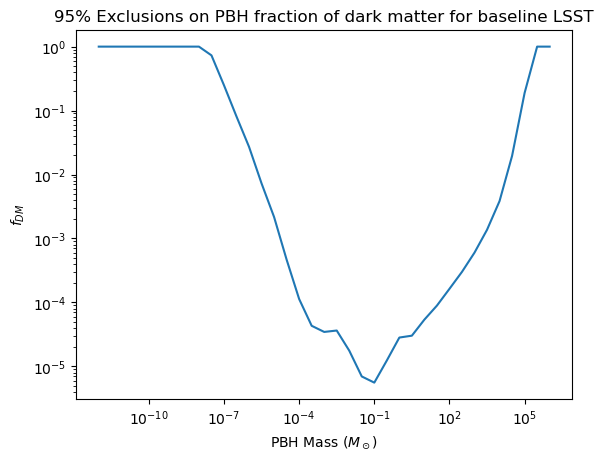

In [23]:
sns.lineplot(exclusion_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST')

In [44]:
exclusion_df.to_csv('LSST-bestcase.txt', sep=' ', index=False)

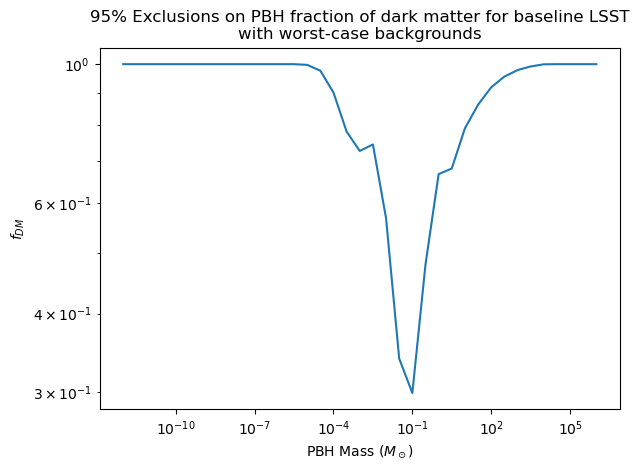

In [287]:
sns.lineplot(exclusion_min_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST\n'
          'with worst-case backgrounds')
plt.tight_layout()
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/exclusions-worst-case-te-0.9-temp.pdf')

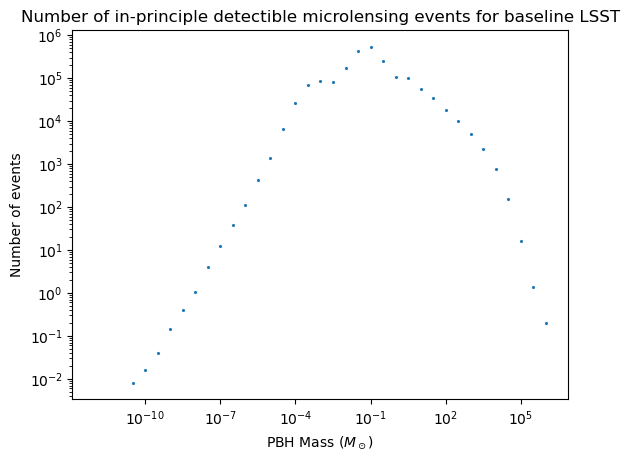

In [30]:
sns.lineplot(det_counts_df, x='pbhmass',y='Detected events (baseline)',linestyle='None',marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'Number of events')
plt.title('Number of in-principle detectible microlensing events for baseline LSST')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/n-events-by-pbhmass.pdf')

In [24]:

def bhmf(m: float, mc=6.3, ms=1.6):
  """Milky way black hole mass density function, as an exponential with cutofff
      defaults to fig 2 of https://arxiv.org/pdf/1006.2834
  Args:
      m (float): Mass in question (SM)
      mc (float): Cutoff mass (SM)
      ms (float): Mass scale (SM)
  """

  return (np.exp((mc-m)/ms)/ms)*(m>mc)

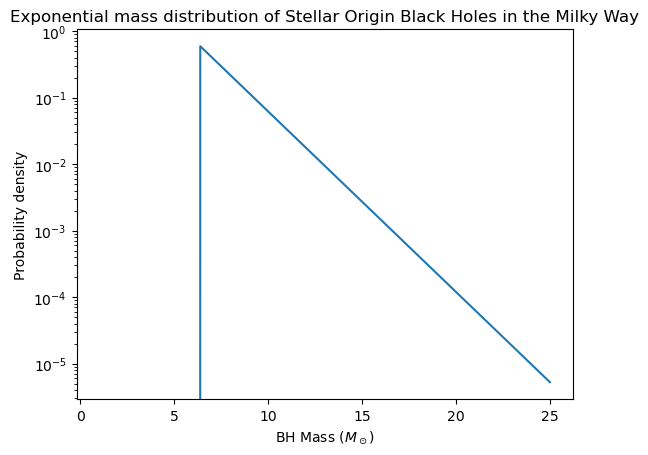

In [52]:
xs = np.linspace(1,25,50)
# ys = np.logspace(-2,0)
ys = bhmf(xs)
plt.plot(xs,ys)
plt.xlabel(r'BH Mass ($M_\odot$)')
plt.ylabel('Probability density')
plt.title('Exponential mass distribution of Stellar Origin Black Holes in the Milky Way')
plt.yscale('log')


In [53]:
scipy.integrate.quad(bhmf,6.3,100)

(0.9999999999999994, 2.1789394282476816e-10)

In [25]:
def get_sobh_counts(m, width=2.):
  return scipy.integrate.quad(bhmf,m/width,m*width)
def get_bucketed_bhs(masses, width=2.):
  """Evaluate number of background indistinguishable SOBHs 
     at some masses, by integrating the mass density function
     around a factor of width to either side of each mass

  Args:
      masses (iterable): List of masses (SM)
      width (float, optional): Factor away from each mass to integrate. Defaults to 2.
  """
  counts = {}
  for m in masses:
    counts[m] = scipy.integrate.quad(bhmf,m/width,m*width)
  return counts

    

In [75]:
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh = {}
for mass, rate in rates_by_mass.items():
  n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
  # print(n_bh_mass)
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    pass
    # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  # print(eff)
  exclusions_sobh[mass] = exclusion_from_rate(rate * eff * (1 + n_bh_mass), rate * eff * n_bh_mass)

In [50]:
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh = {}
for mass, rate in rates_by_mass.items():
  n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
  # print(n_bh_mass)
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    pass
    # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  # print(eff)
  exclusions_sobh[mass] = exclusion_from_rate(rate * eff * (1 + n_bh_mass), rate * eff * n_bh_mass)

  exclusions[mass] = exclusion_from_rate(rate * eff, 0)

In [79]:
eff_df

,eff,pbhmass,opsim
0,0.0082,1.000000e-12,baseline_v3.6_10yrs
1,0.0082,3.162278e-12,baseline_v3.6_10yrs
2,0.0083,1.000000e-11,baseline_v3.6_10yrs
3,0.0089,3.162278e-11,baseline_v3.6_10yrs
4,0.0087,1.000000e-10,baseline_v3.6_10yrs
5,0.0086,3.162278e-10,baseline_v3.6_10yrs
6,0.0078,1.000000e-09,baseline_v3.6_10yrs
7,0.0096,3.162278e-09,baseline_v3.6_10yrs
8,0.0065,1.000000e-08,baseline_v3.6_10yrs
9,0.0101,3.162278e-08,baseline_v3.6_10yrs


In [87]:
pbhmass = 10
npbh = tot_dm/pbhmass

print(pbhmass)
print(rates_by_mass[pbhmass]*n_bh/npbh)

print(eff_df[eff_df['pbhmass']==pbhmass]['eff'].iloc[0]*rates_by_mass[pbhmass]*n_bh/npbh)

10
1025.963503649635
407.2049145985401


In [84]:
eff_df[np.isclose(eff_df['pbhmass'],pbhmass)]['eff']

Series([], Name: eff, dtype: float64)

In [86]:
eff_df['pbhmass']

0     1.000000e-12
1     3.162278e-12
2     1.000000e-11
3     3.162278e-11
4     1.000000e-10
5     3.162278e-10
6     1.000000e-09
7     3.162278e-09
8     1.000000e-08
9     3.162278e-08
10    1.000000e-07
11    3.162278e-07
12    1.000000e-06
13    3.162278e-06
14    1.000000e-05
15    3.162278e-05
16    1.000000e-04
17    3.162278e-04
18    1.000000e-03
19    3.162278e-03
20    1.000000e-02
21    3.162278e-02
22    1.000000e-01
23    3.162278e-01
24    1.000000e+00
25    3.162278e+00
26    1.000000e+01
27    3.162278e+01
28    1.000000e+02
29    3.162278e+02
30    1.000000e+03
31    3.162278e+03
32    1.000000e+04
33    3.162278e+04
34    1.000000e+05
35    3.162278e+05
36    1.000000e+06
Name: pbhmass, dtype: float64

In [53]:
exclusion_sobh_df = pd.DataFrame(exclusions_sobh.items(), columns=['pbhmass', 'exclusion'])

In [51]:
exclusion_df = pd.DataFrame(exclusions.items(), columns=['pbhmass', 'exclusion'])

Text(0.5, 1.0, '95% Exclusions on PBH fraction of dark matter for baseline LSST\nwith stellar origin BH backgrounds')

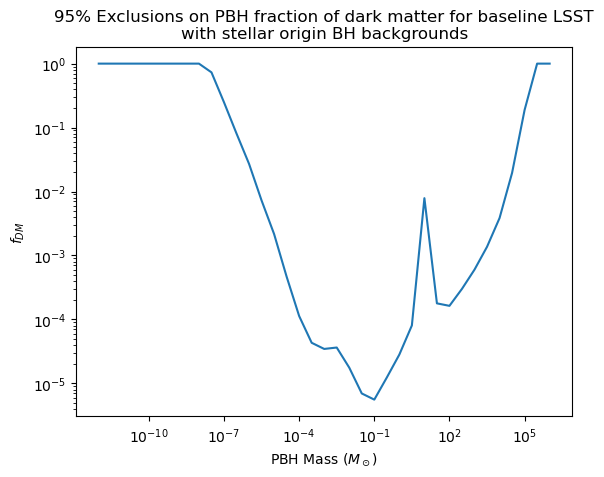

In [54]:
sns.lineplot(exclusion_sobh_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST\n'
          'with stellar origin BH backgrounds')

Text(0.5, 1.0, '95% Exclusions on PBH fraction of dark matter for baseline LSST')

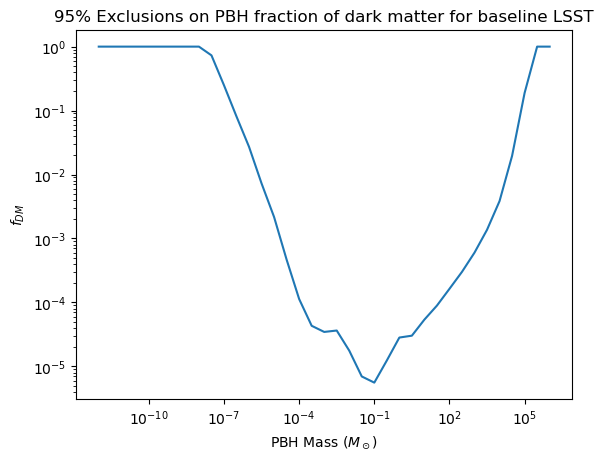

In [52]:
sns.lineplot(exclusion_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST')

In [57]:
exclusion_sobh_df.to_csv('LSST-bestcase-sobh.txt', sep=' ', index=False, header=False)

In [147]:
real_det_eff=0.5
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh_in_time = []
for mass, rate in rates_by_mass.items():
  n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
  # print(n_bh_mass)
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    pass
    # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  # print(eff)
  # for t in np.arange(1./12,10.,1./12):

  for t in np.logspace(-4,1,100):
    exclusions_sobh_in_time.append([
      mass,
      t*12,
      exclusion_from_rate(real_det_eff*rate * eff * (1 + n_bh_mass)*t/10, real_det_eff*rate * eff * n_bh_mass*t/10)
    ])
                                  

In [148]:
exclusions_sobh_in_time_df = pd.DataFrame(exclusions_sobh_in_time,columns=['pbhmass','time (months)', 'exclusion'])

In [149]:
exclusions_sobh_in_time_df

,pbhmass,time (months),exclusion
0,1.000000e-12,0.001200,1.0
1,1.000000e-12,0.001348,1.0
2,1.000000e-12,0.001514,1.0
3,1.000000e-12,0.001701,1.0
4,1.000000e-12,0.001911,1.0
...,...,...,...
3695,1.000000e+06,75.363497,1.0
3696,1.000000e+06,84.657628,1.0
3697,1.000000e+06,95.097948,1.0
3698,1.000000e+06,106.825810,1.0


In [153]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/detections/*.pickle')
print(result_files_wide10k)
time_mass_eff=[]
for file in result_files_wide10k:
  with open(file,'rb') as f:
    info,results = pickle.load(f)
    elapsed = float(info['constraint'].split('<')[-1])
    eff = np.sum(results)/results.shape[0]
    mass = info['pbhmass']
    time_mass_eff.append((elapsed, mass, eff))

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<1156.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<116.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<12.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<2054.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<206.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<21.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_night<3653.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/detections/baseline_v3.6_10yrs_1.0000e+00sm_nig

In [156]:
time_eff_df = pd.DataFrame(time_mass_eff, columns=['time', 'pbhmass', 'eff' ])

In [177]:
time_eff_df

,time,pbhmass,eff
0,1156.0,1.000000e+00,0.1007
1,116.0,1.000000e+00,0.0071
2,12.0,1.000000e+00,0.0002
3,2054.0,1.000000e+00,0.1755
4,206.0,1.000000e+00,0.0128
...,...,...,...
476,37.0,3.162278e-12,0.0000
477,4.0,3.162278e-12,0.0000
478,65.0,3.162278e-12,0.0000
479,650.0,3.162278e-12,0.0011


In [194]:
real_det_eff=.5
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh_in_time = []
for mass, rate in rates_by_mass.items():

  for t in sorted(time_eff_df['time'].unique()):
    n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
    # print(n_bh_mass)
    if mass not in time_eff_df['pbhmass'].unique():
      continue
    try:
      eff  = time_eff_df[(np.isclose(time_eff_df['pbhmass'],mass) )
                         & (t==time_eff_df['time'])]['eff'].iloc[0]
    except:
      pass
      # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
    # print(mass)
    # print(eff)
    # for t in np.arange(1./12,10.,1./12):

    exclusions_sobh_in_time.append([
      mass,
      t,
      exclusion_from_rate(real_det_eff*rate * eff * (1 + n_bh_mass), real_det_eff*rate * eff * n_bh_mass)
    ])
                                  

In [195]:
time_eff_df[(np.isclose(time_eff_df['pbhmass'],mass) )
                         & (t==time_eff_df['time'])]['eff'].iloc[0]

0.1956

In [196]:
exclusions_sobh_in_time

[[1e-12, 4.0, 1],
 [1e-12, 7.0, 1],
 [1e-12, 12.0, 1],
 [1e-12, 21.0, 1],
 [1e-12, 37.0, 1],
 [1e-12, 65.0, 1],
 [1e-12, 116.0, 1],
 [1e-12, 206.0, 1],
 [1e-12, 366.0, 1],
 [1e-12, 650.0, 1],
 [1e-12, 1156.0, 1],
 [1e-12, 2054.0, 1],
 [1e-12, 3653.0, 1],
 [3.1622776601683794e-12, 4.0, 1],
 [3.1622776601683794e-12, 7.0, 1],
 [3.1622776601683794e-12, 12.0, 1],
 [3.1622776601683794e-12, 21.0, 1],
 [3.1622776601683794e-12, 37.0, 1],
 [3.1622776601683794e-12, 65.0, 1],
 [3.1622776601683794e-12, 116.0, 1],
 [3.1622776601683794e-12, 206.0, 1],
 [3.1622776601683794e-12, 366.0, 1],
 [3.1622776601683794e-12, 650.0, 1],
 [3.1622776601683794e-12, 1156.0, 1],
 [3.1622776601683794e-12, 2054.0, 1],
 [3.1622776601683794e-12, 3653.0, 1],
 [1e-11, 4.0, 1],
 [1e-11, 7.0, 1],
 [1e-11, 12.0, 1],
 [1e-11, 21.0, 1],
 [1e-11, 37.0, 1],
 [1e-11, 65.0, 1],
 [1e-11, 116.0, 1],
 [1e-11, 206.0, 1],
 [1e-11, 366.0, 1],
 [1e-11, 650.0, 1],
 [1e-11, 1156.0, 1],
 [1e-11, 2054.0, 1],
 [1e-11, 3653.0, 1],
 [3.1622776601

In [197]:
eff

0.1956

In [198]:
exclusions_sobh_in_time_df = pd.DataFrame(exclusions_sobh_in_time,columns=['pbhmass','time (days)', 'exclusion'])

<Axes: ylabel='Frequency'>

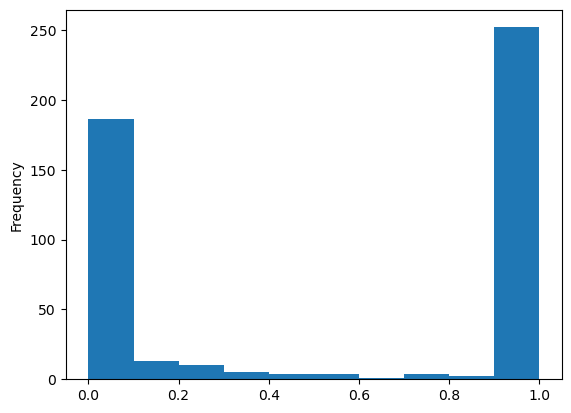

In [199]:
exclusions_sobh_in_time_df['exclusion'].plot.hist()

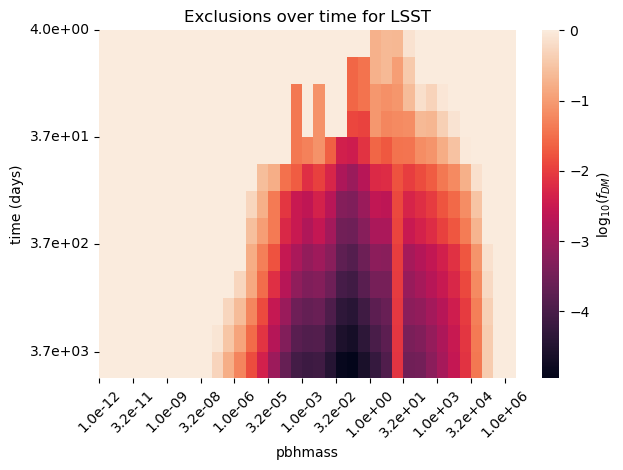

In [200]:
df_pivot = np.log10(exclusions_sobh_in_time_df.pivot(index="time (days)", columns="pbhmass", values="exclusion"))
sns.heatmap(df_pivot, fmt='.1e',cbar_kws={'label': r'log$_{10}(f_{DM})$'})
# # Format x-axis labels (columns)
# plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1e}'))

# # Format y-axis labels (index)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}'))

# plt.yscale('log')

# Control y-axis ticks to show integer indices
ax = plt.gca()
y_tick_locs = np.arange(0, len(df_pivot.index), 4)  # Example: every 2nd tick
y_tick_labels = [f'{df_pivot.index[int(i)]:.1e}' for i in y_tick_locs]  # Simplified labels

ax.set_yticks(y_tick_locs)
ax.set_yticklabels(y_tick_labels)

# Control x-axis (if needed)
x_tick_locs = np.arange(0, len(df_pivot.columns), 3)  # Example: every 3rd tick
x_tick_labels = [f'{df_pivot.columns[int(i)]:.1e}' for i in x_tick_locs]  # Scientific notation

ax.set_xticks(x_tick_locs)
ax.set_xticklabels(x_tick_labels, rotation=45)

ax.set_title('Exclusions over time for LSST')
plt.tight_layout()
# plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/exclusions/exclusions-over-time-simple.pdf')

In [ ]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/Fisher/*.pickle')
print(result_files_wide10k)
time_mass_eff_fisher=[]
results_fisher=[]
for file in result_files_wide10k:
  with open(file,'rb') as f:
    info,results = pickle.load(f)
    results_fisher.append((info, results))
    elapsed = float(info['constraint'].split('<')[-1])
    eff = np.sum(results<.05)/results.shape[0]
    mass = info['pbhmass']
    time_mass_eff_fisher.append((elapsed, mass, eff))
time_eff_df_fisher = pd.DataFrame(time_mass_eff_fisher, columns=['time', 'pbhmass', 'eff' ])

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<1156.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<116.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<12.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<2054.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<206.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<21.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<3653.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<366.0.pickle', '/Volumes/thes

In [ ]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/Fisher/*.pickle')
print(result_files_wide10k)
time_mass_eff_fisher=[]
results_fisher=[]
for file in result_files_wide10k:
  with open(file,'rb') as f:
    info,results = pickle.load(f)
    results_fisher.append((info, results))
    elapsed = float(info['constraint'].split('<')[-1])
    eff = np.sum(results<.05)/results.shape[0]
    mass = info['pbhmass']
    time_mass_eff_fisher.append((elapsed, mass, eff))
time_eff_df_fisher = pd.DataFrame(time_mass_eff_fisher, columns=['time', 'pbhmass', 'eff' ])

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<1156.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<116.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<12.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<206.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<21.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<366.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<37.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher/baseline_v3.6_10yrs_1.0000e+00sm_night<4.0.pickle', '/Volumes/thesis/ru

In [27]:
real_det_eff=1
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh_in_time_fisher = []
for mass, rate in rates_by_mass.items():

  for t in sorted(time_eff_df_fisher['time'].unique()):
    n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
    # print(n_bh_mass)
    if mass not in time_eff_df_fisher['pbhmass'].unique():
      continue
    try:
      eff  = time_eff_df_fisher[(np.isclose(time_eff_df_fisher['pbhmass'],mass) )
                         & (t==time_eff_df_fisher['time'])]['eff'].iloc[0]
    except:
      pass
      # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
    # print(mass)
    # print(eff)
    # for t in np.arange(1./12,10.,1./12):

    exclusions_sobh_in_time_fisher.append([
      mass,
      t,
      exclusion_from_rate(real_det_eff*rate * eff * (1 + n_bh_mass) * t/3652, real_det_eff*rate * eff * n_bh_mass * t/3652)
    ])
                                  

In [28]:
exclusions_sobh_in_time_df_fisher = pd.DataFrame(exclusions_sobh_in_time_fisher,columns=['pbhmass','time (days)', 'exclusion'])

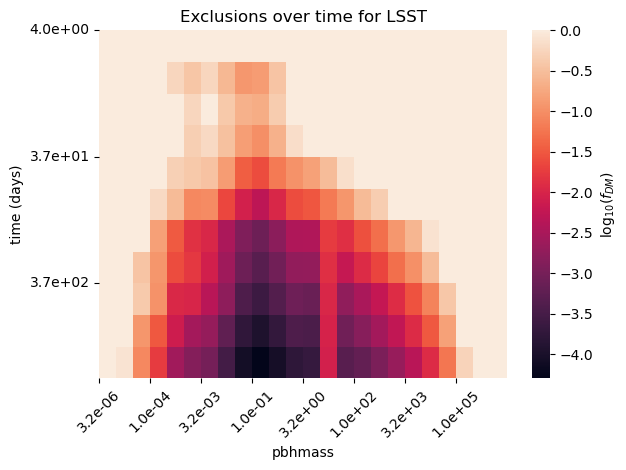

In [29]:
df_pivot = np.log10(exclusions_sobh_in_time_df_fisher.pivot(index="time (days)", columns="pbhmass", values="exclusion"))
sns.heatmap(df_pivot, fmt='.1e',cbar_kws={'label': r'log$_{10}(f_{DM})$'})
# # Format x-axis labels (columns)
# plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1e}'))

# # Format y-axis labels (index)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}'))

# plt.yscale('log')

# Control y-axis ticks to show integer indices
ax = plt.gca()
y_tick_locs = np.arange(0, len(df_pivot.index), 4)  # Example: every 2nd tick
y_tick_labels = [f'{df_pivot.index[int(i)]:.1e}' for i in y_tick_locs]  # Simplified labels

ax.set_yticks(y_tick_locs)
ax.set_yticklabels(y_tick_labels)

# Control x-axis (if needed)
x_tick_locs = np.arange(0, len(df_pivot.columns), 3)  # Example: every 3rd tick
x_tick_labels = [f'{df_pivot.columns[int(i)]:.1e}' for i in x_tick_locs]  # Scientific notation

ax.set_xticks(x_tick_locs)
ax.set_xticklabels(x_tick_labels, rotation=45)

ax.set_title('Exclusions over time for LSST')
plt.tight_layout()
# plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/exclusions/exclusions-over-time-simple.pdf')

In [267]:
time_eff_df_fisher[time_eff_df_fisher['time']==7]

,time,pbhmass,eff
5,7.000e+00,1.000e+00,7.000e-04
11,7.000e+00,1.000e+01,7.000e-04
17,7.000e+00,1.000e+02,6.000e-04
23,7.000e+00,1.000e+03,0.000e+00
29,7.000e+00,1.000e+04,3.000e-04
35,7.000e+00,1.000e+05,0.000e+00
41,7.000e+00,1.000e+06,1.000e-04
47,7.000e+00,1.000e-01,5.000e-04
53,7.000e+00,1.000e-02,6.000e-04
59,7.000e+00,1.000e-03,1.000e-04


In [263]:
pd.options.display.float_format = '{:.3e}'.format

In [36]:
result_files_wide10k

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<1156.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<116.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<12.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<2054.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<206.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<21.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<3653.0.pickle',
 '/Volumes/thesis/rubin-sim/userdata/opsim_ml/w

In [115]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/Fisher_Npts_Nights/*.pickle')
result_files_wide10k = result_files_wide10k+glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/Fisher_Npts_Nights_Oversampled/*.pickle')  
print(result_files_wide10k)
time_mass_eff_fisher={}
# results_fisher=[]
for file in result_files_wide10k:
  with open(file,'rb') as f:
    info,result_fisher, result_n, result_nights = pickle.load(f)
    # results_fisher.append((info, result_fisher))
    elapsed = float(info['constraint'].split('<')[-1])
    eff = np.sum((result_fisher<.05)&(result_n>=10)&(result_nights>=10))/result_fisher.shape[0]
    mass = info['pbhmass']
    time_mass_eff_fisher[(elapsed, mass)]=eff
# time_eff_df_fisher = pd.DataFrame(time_mass_eff_fisher, columns=['time', 'pbhmass', 'eff' ])

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<1156.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<116.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<12.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<2054.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<206.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<21.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<3653.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-

In [119]:
time_mass_eff_fisher

{(1156.0, 1.0): 0.1252,
 (116.0, 1.0): 0.0642,
 (12.0, 1.0): 0.0,
 (2054.0, 1.0): 0.1272,
 (206.0, 1.0): 0.0654,
 (21.0, 1.0): 0.0,
 (3653.0, 1.0): 0.1329,
 (366.0, 1.0): 0.08,
 (37.0, 1.0): 0.0,
 (4.0, 1.0): 0.0,
 (65.0, 1.0): 0.0046,
 (650.0, 1.0): 0.1,
 (7.0, 1.0): 0.0,
 (1156.0, 10.0): 0.2476,
 (116.0, 10.0): 0.0845,
 (12.0, 10.0): 0.0,
 (2054.0, 10.0): 0.2582,
 (206.0, 10.0): 0.1023,
 (21.0, 10.0): 0.0,
 (3653.0, 10.0): 0.2777,
 (366.0, 10.0): 0.1617,
 (37.0, 10.0): 0.0001,
 (4.0, 10.0): 0.0,
 (65.0, 10.0): 0.0056,
 (650.0, 10.0): 0.1861,
 (7.0, 10.0): 0.0,
 (1156.0, 100.0): 0.3404,
 (116.0, 100.0): 0.0758,
 (12.0, 100.0): 0.0,
 (2054.0, 100.0): 0.3658,
 (206.0, 100.0): 0.0998,
 (21.0, 100.0): 0.0,
 (3653.0, 100.0): 0.4045,
 (366.0, 100.0): 0.2033,
 (37.0, 100.0): 0.0001,
 (4.0, 100.0): 0.0,
 (65.0, 100.0): 0.0037,
 (650.0, 100.0): 0.2494,
 (7.0, 100.0): 0.0,
 (1156.0, 1000.0): 0.3266,
 (116.0, 1000.0): 0.0543,
 (12.0, 1000.0): 0.0,
 (2054.0, 1000.0): 0.3717,
 (206.0, 1000.0): 0.0

In [126]:
time_eff_df_fisher=pd.DataFrame(time_mass_eff_fisher.keys(), columns=['time', 'pbhmass' ]).join(pd.DataFrame(time_mass_eff_fisher.values(),columns=['eff']))

In [113]:
result_fisher.shape[0]

100000

In [127]:
time_eff_df_fisher[time_eff_df_fisher['pbhmass']==.0001]

,time,pbhmass,eff
130,1156.0,0.0001,0.00007
131,116.0,0.0001,0.00014
132,12.0,0.0001,0.00000
133,2054.0,0.0001,0.00016
134,206.0,0.0001,0.00008
135,21.0,0.0001,0.00000
136,3653.0,0.0001,0.00019
137,366.0,0.0001,0.00005
138,37.0,0.0001,0.00000
139,4.0,0.0001,0.00000


In [104]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/Fisher_Npts_Nights/*.pickle')
result_files_wide10k = result_files_wide10k+glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k-partials/Fisher_Npts_Nights_Oversampled/*.pickle')     
print(result_files_wide10k)
# time_mass_eff_fisher=[]
# results_fisher=[]
for file in result_files_wide10k:
  with open(file,'rb') as f:
    info,result_fisher, result_n, result_nights = pickle.load(f)
    # results_fisher.append((info, result_fisher))
    elapsed = float(info['constraint'].split('<')[-1])
    eff = np.sum((result_fisher<.05)&(result_n>=10)&(result_nights>=10))/result_fisher.shape[0]
    mass = info['pbhmass']
    print(elapsed)
    # time_mass_eff_fisher.append((elapsed, mass, eff))
# time_eff_df_fisher = pd.DataFrame(time_mass_eff_fisher, columns=['time', 'pbhmass', 'eff' ])

['/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<1156.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<116.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<12.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<2054.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<206.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<21.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-partials/Fisher_Npts_Nights/baseline_v3.6_10yrs_1.0000e+00sm_night<3653.0.pickle', '/Volumes/thesis/rubin-sim/userdata/opsim_ml/wide10k-

In [37]:
elapsed

7.0

In [129]:
real_det_eff=1
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh_in_time_fisher = []
exclusions_in_time_fisher = []
exclusions_justsobh_in_time_fisher = []
for mass, rate in rates_by_mass.items():

  for t in sorted(time_eff_df_fisher['time'].unique()):
    n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
    # print(n_bh_mass)
    if mass not in time_eff_df_fisher['pbhmass'].unique():
      continue
    try:
      eff  = time_eff_df_fisher[(np.isclose(time_eff_df_fisher['pbhmass'],mass) )
                         & (t==time_eff_df_fisher['time'])]['eff'].iloc[0]
    except:
      pass
      # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
    # print(mass)
    # print(eff)
    # for t in np.arange(1./12,10.,1./12):
    ndetections = real_det_eff*rate * eff * (1 + n_bh_mass) * t/3652

    exclusions_sobh_in_time_fisher.append([
      mass,
      t,
      eff,
      ndetections,
      exclusion_from_rate(ndetections, real_det_eff*rate * eff * n_bh_mass * t/3652)
    ])
    exclusions_justsobh_in_time_fisher.append([
      mass,
      t,
      eff,
      ndetections,
      *bounds_from_rate(real_det_eff*rate * eff *( n_bh_mass) * t/3652, real_det_eff*rate * eff * (n_bh_mass) * t/3652)
    ])
    exclusions_in_time_fisher.append([
      mass,
      t,
      eff,
      ndetections,
      exclusion_from_rate(real_det_eff*rate * eff * t/3652, 0)
    ])
                                  

In [98]:
bounds_from_rate(real_det_eff*rate * eff * (n_bh_mass) * t/3652, real_det_eff*rate * eff * (n_bh_mass) * t/3652)

(0, 1)

In [99]:
exclusions_justsobh_in_time_df_fisher = pd.DataFrame(exclusions_justsobh_in_time_fisher,columns=['pbhmass','time (days)', 'eff','ndetections', 'min','max'])

In [100]:
exclusions_justsobh_in_time_df_fisher['time (days)'].max()

3653.0

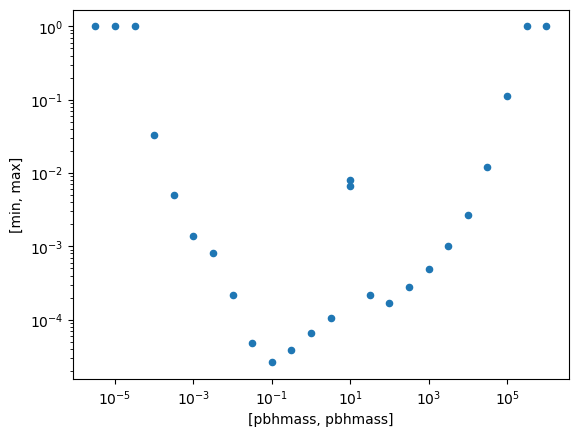

In [101]:
df = exclusions_justsobh_in_time_df_fisher[exclusions_justsobh_in_time_df_fisher['time (days)']==exclusions_justsobh_in_time_df_fisher['time (days)'].max()]
# fig,ax=plt.subplots()
df.plot.scatter(['pbhmass','pbhmass'],['min','max'])
# exclusions_justsobh_in_time_df_fisher.plot.scatter('pbhmass','max')
plt.yscale('log')
plt.xscale('log')

In [54]:
exclusions_in_time_df_fisher = pd.DataFrame(exclusions_in_time_fisher,columns=['pbhmass','time (days)', 'eff','ndetections', 'exclusion'])

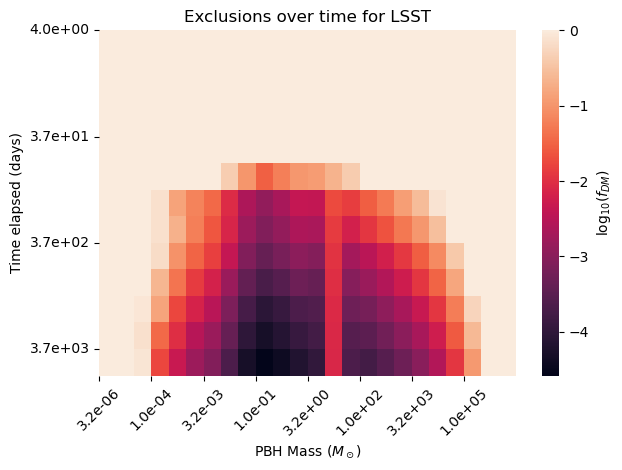

In [138]:
exclusions_sobh_in_time_df_fisher = pd.DataFrame(exclusions_sobh_in_time_fisher,columns=['pbhmass','time (days)', 'eff','ndetections', 'exclusion'])
df_pivot = np.log10(exclusions_sobh_in_time_df_fisher.pivot(index="time (days)", columns="pbhmass", values="exclusion"))
sns.heatmap(df_pivot, fmt='.1e',cbar_kws={'label': r'log$_{10}(f_{DM})$'})
# # Format x-axis labels (columns)
# plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1e}'))

# # Format y-axis labels (index)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}'))

# plt.yscale('log')

# Control y-axis ticks to show integer indices
ax = plt.gca()
y_tick_locs = np.arange(0, len(df_pivot.index), 4)  # Example: every 2nd tick
y_tick_labels = [f'{df_pivot.index[int(i)]:.1e}' for i in y_tick_locs]  # Simplified labels

ax.set_yticks(y_tick_locs)
ax.set_yticklabels(y_tick_labels)

# Control x-axis (if needed)
x_tick_locs = np.arange(0, len(df_pivot.columns), 3)  # Example: every 3rd tick
x_tick_labels = [f'{df_pivot.columns[int(i)]:.1e}' for i in x_tick_locs]  # Scientific notation

ax.set_xticks(x_tick_locs)
ax.set_xticklabels(x_tick_labels, rotation=45)

plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel("Time elapsed (days)")
ax.set_title('Exclusions over time for LSST')
plt.tight_layout()
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/exclusions/exclusions-over-time-fisher-npts-nights-10k-oversampled-sobh.pdf')

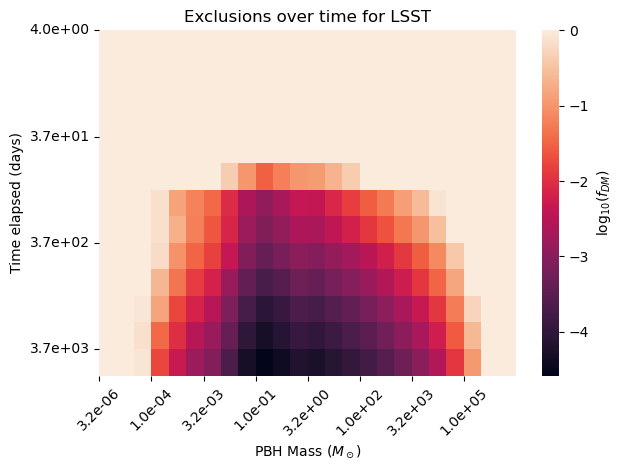

In [137]:
exclusions_in_time_df_fisher = pd.DataFrame(exclusions_in_time_fisher,columns=['pbhmass','time (days)', 'eff','ndetections', 'exclusion'])
df_pivot = np.log10(exclusions_in_time_df_fisher.pivot(index="time (days)", columns="pbhmass", values="exclusion"))
sns.heatmap(df_pivot, fmt='.1e',cbar_kws={'label': r'log$_{10}(f_{DM})$'})
# # Format x-axis labels (columns)
# plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1e}'))

# # Format y-axis labels (index)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}'))

# plt.yscale('log')

# Control y-axis ticks to show integer indices
ax = plt.gca()
y_tick_locs = np.arange(0, len(df_pivot.index), 4)  # Example: every 2nd tick
y_tick_labels = [f'{df_pivot.index[int(i)]:.1e}' for i in y_tick_locs]  # Simplified labels

ax.set_yticks(y_tick_locs)
ax.set_yticklabels(y_tick_labels)

# Control x-axis (if needed)
x_tick_locs = np.arange(0, len(df_pivot.columns), 3)  # Example: every 3rd tick
x_tick_labels = [f'{df_pivot.columns[int(i)]:.1e}' for i in x_tick_locs]  # Scientific notation

ax.set_xticks(x_tick_locs)
ax.set_xticklabels(x_tick_labels, rotation=45)
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel("Time elapsed (days)")

ax.set_title('Exclusions over time for LSST')
plt.tight_layout()
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/exclusions/exclusions-over-time-fisher-npts-nights-10k-oversampled.pdf')

In [111]:
exclusions_sobh_in_time_df_fisher[np.isclose(exclusions_sobh_in_time_df_fisher['pbhmass'],1*10**(-4))]

,pbhmass,time (days),eff,ndetections,exclusion
39,0.0001,4.0,0.0000,0.000000,1.000000
40,0.0001,7.0,0.0000,0.000000,1.000000
41,0.0001,12.0,0.0000,0.000000,1.000000
42,0.0001,21.0,0.0000,0.000000,1.000000
43,0.0001,37.0,0.0000,0.000000,1.000000
44,0.0001,65.0,0.0000,0.000000,1.000000
45,0.0001,116.0,0.0002,5.783216,0.518742
46,0.0001,206.0,0.0000,0.000000,1.000000
47,0.0001,366.0,0.0000,0.000000,1.000000
48,0.0001,650.0,0.0000,0.000000,1.000000


In [44]:
tenyrdf = exclusions_sobh_in_time_df_fisher[np.isclose(exclusions_sobh_in_time_df_fisher['time (days)'],3653.0)]

In [55]:
tenyrdf = exclusions_in_time_df_fisher[np.isclose(exclusions_in_time_df_fisher['time (days)'],3653.0)]

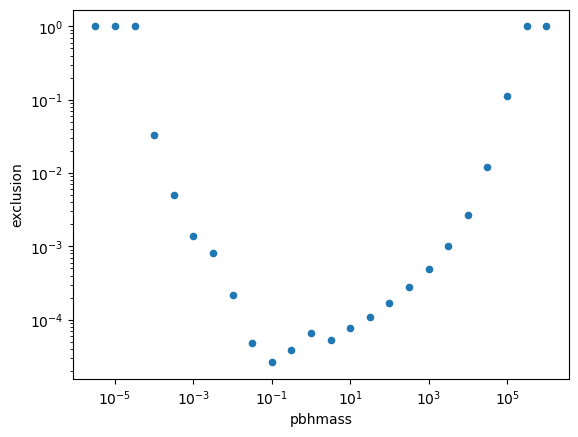

In [56]:
tenyrdf.plot.scatter('pbhmass','exclusion')
plt.yscale('log')
plt.xscale('log')

In [57]:
tenyrdf[['pbhmass','exclusion']].to_csv('LSST-bestcase-strict.txt', sep=' ', index=False, header=False)